In [1]:
from dataloader import HESignature, HEImage
from argparse import Namespace
from dtime.trackers import timetracker
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
from peft import LoraConfig
from networks import LoRAFactory
from models import HESingIF
import torch

ImportError: attempted relative import with no known parent package

In [3]:
dict = {}
dict["img_dir"] = (
    "/cluster/CBIO/data1/mblons/orion/data/CRC_TILE_SIGNATURE/tile_feat_20x_224px_0px_overlap/tile/"
)
dict["input_path"] = None
dict["target_path"] = None
dict["test_fold"] = 0
dict["device"] = "cpu"
dict["img_size"] = 224
# change for encoder_name
dict["encoder"] = "hoptimus1"
dict["feature_dim"] = 1536
dict["instance_transf"] = True
dict["optimizer"] = "adam"
dict["lr"] = 2e-4
dict["lr_scheduler"] = "cos"
dict["patience_lr"] = None
dict["epochs"] = 15
dict["patience"] = None
dict["batch_size"] =64
dict["use_val"] = True
dict["num_workers"] = 0
dict["criterion"] = "mse"
dict["ref_metric"] = "mean_val_loss"
args = Namespace(**dict)
tracker = timetracker(verbose=1)

In [ ]:
all_available = {f for f in os.listdir(args.img_dir) if f.endswith(("jpeg"))}
print(f"N total = {len(all_available)} tiles in {img_dir}")

In [5]:
# add lora config arguments in args
# If I need to only apply lora on q and v -> will need custom lora layers
tracker.tic()
peft_cfg = LoraConfig(
    r=8,
    lora_alpha=1,
    target_modules=["qkv"],
    lora_dropout=0.1,
    lora_bias="none",
)

model_lora = LoRAFactory(args, peft_cfg)
print(f"precision = {model_lora.precision}")
model_lora.print_lora_summary()
model_lora.print_summary()
time = tracker.toc()

precision = {'backbone': torch.float32, 'lora': torch.float32, 'head': torch.float32}
trainable params: 2,150,400 || all params: 1,136,924,672 || trainable%: 0.1891
Layer (type:depth-idx)                                            Param #
Sequential                                                        --
├─PeftModel: 1-1                                                  --
│    └─LoraModel: 2-1                                             --
│    │    └─VisionTransformer: 3-1                                400,896
│    │    │    └─PatchEmbed: 4-1                                  (904,704)
│    │    │    └─Dropout: 4-2                                     --
│    │    │    └─Identity: 4-3                                    --
│    │    │    └─Identity: 4-4                                    --
│    │    │    └─Sequential: 4-5                                  1,135,616,000
│    │    │    └─LayerNorm: 4-6                                   (3,072)
│    │    │    └─Identity: 4-7             

In [ ]:
tracker.tic()
dataset = HEImage(
    args,
    transform=model_lora.transform,
    use_train=False,
    predict=True,
)
print(f"dataset size = {dataset.__len__()}")
print(f"dataset extension = {dataset.ext}")
print(f"dataset norm = {dataset.transform}")
time = tracker.toc()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6165389..1.6696036].


image shape = (224, 224, 3)
image type = uint8


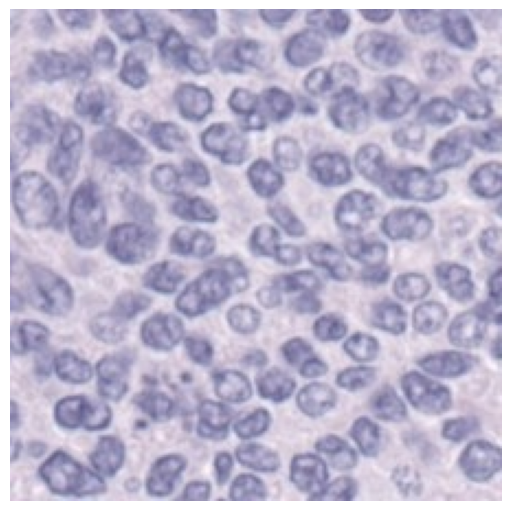

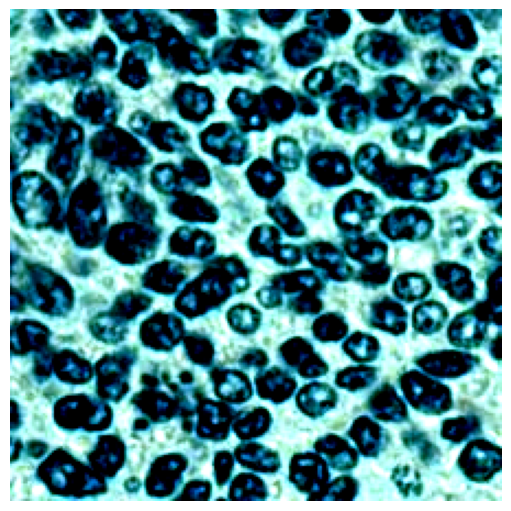

In [26]:
path = os.path.join(args.img_dir, "18459_LSP10375_US_SCAN_OR_001__092147-registered.ome_43232_10304_224_224.jpeg")
image = np.asarray(Image.open(path))
print(f"image shape = {image.shape}")
print(f"image type = {image.dtype}")
fig, ax = plt.subplots(1, 1, figsize=(5, 5), layout="constrained")
ax.set_axis_off()
ax.imshow(image, aspect="equal")


he = Image.fromarray(image).convert("RGB")
he = model_lora.transform(he)
fig, ax = plt.subplots(1, 1, figsize=(5, 5), layout="constrained")
ax.set_axis_off()
ax.imshow(he.permute(1, 2, 0), aspect="equal")
plt.show()

In [ ]:
if args.input_path:
    print(f"image is in test fold = {dataset.img_to_fold[os.path.basename(path)]}")
    print(f"image is in dataset = {dataset._is_in_db(path)}")

idx_in_dataset = dataset.input_files.index(path)
print(f"image index = {idx_in_dataset}")

image = np.asarray(Image.open(path))
print(f"image shape = {image.shape}")
print(f"image type = {image.dtype}")
fig, ax = plt.subplots(1, 1, figsize=(5, 5), layout="constrained")
ax.set_axis_off()
ax.imshow(image, aspect="equal")

image_tranf = dataset.get_image(path)
fig, ax = plt.subplots(1, 1, figsize=(5, 5), layout="constrained")
ax.set_axis_off()
ax.imshow(image_tranf, aspect="equal")
plt.show()

In [ ]:
if args.target_path is not None:
    signature = dataset.get_signature(idx_in_dataset)
    print(f"proteo signature = {signature}")
    print(all(signature == dataset.get_signature_from_path(path)))
    print(all(signature == dataset.target_dict[path]))
    he, target = dataset.__getitem__(idx_in_dataset)
    print(all(target == signature))
else:
    he = dataset.__getitem__(idx_in_dataset)
print(f"input tensor shape = {he.shape}")
print(f"input tensor type = {he.dtype}")
fig, ax = plt.subplots(1, 1, figsize=(5, 5), layout="constrained")
ax.set_axis_off()
ax.imshow(he.permute(1, 2, 0), aspect="equal")
plt.show()

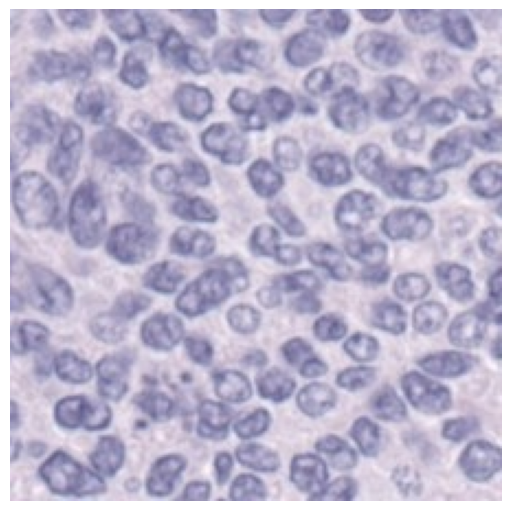

In [7]:
def undo_norm(tensor, mean, std):
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor

he_back = undo_norm(tensor=he, mean=[0.707223, 0.578729, 0.703617], std=[0.211883, 0.230117, 0.177517])
fig, ax = plt.subplots(1, 1, figsize=(5, 5), layout="constrained")
ax.set_axis_off()
ax.imshow(he_back.permute(1, 2, 0), aspect="equal")
plt.show()

In [ ]:
model = HESingIF(args, with_data=False)
if model.train_loader is not None and model.val_loader is not None:
    print(f"train dataset lenght = {len(model.train_loader) * args.batch_size} imgs")
    print(f"valid dataset lenght = {len(model.val_loader)} imgs")

model.network.eval()

pred = model.predict(he.unsqueeze(0))
print(f"tensor pred = {pred}")

pred = pred.numpy()
print(f"array pred = {pred}")

# dataloader 
if model.train_loader is not None:
    input_batch, target_batch = next(iter(model.train_loader))
    print(f"input_batch shape = {input_batch.shape}, target_batch shape = {target_batch.shape}")

    for idx in range(input_batch.shape[0]):
        fig, ax = plt.subplots(1, 2, figsize=(5, 5), layout="constrained")
        ax[0].set_axis_off()
        ax[0].imshow(input_batch[idx, ...].permute(1, 2, 0), aspect="equal")
        ax[1].set_axis_off()
        ax[1].imshow(undo_norm(tensor=input_batch[idx, ...], mean=[0.707223, 0.578729, 0.703617], std=[0.211883, 0.230117, 0.177517]).permute(1, 2, 0), aspect="equal")
    plt.show()

In [27]:
from predict import load_model_from_path

model_path = "/cluster/CBIO/data1/mblons/orion/result/hoptimus1_lora_small_cv_1_folds_1_repeats_2025_08_06/test_0/rep_0/model_best.pt.tar"

model_trained = load_model_from_path(model_path, device="cpu")

model_trained.network.eval()

pred = model_trained.predict(he.unsqueeze(0))
print(f"tensor pred = {pred}")
print(f"tensor dtype = {pred.dtype}")

ValueError: not enough values to unpack (expected 4, got 3)